# Диалоговые системы и стратегии управления контекстом

> Внимание! Материал ноутбука подходит для работы в Google Colaboratory. Мы не можем гарантировать стабильную работу кода на личных устройствах и на других системах виртуализации.

## Введение

На занятии 5 агент получил память: научился выносить факты наружу и доставать их по смыслу запроса. Но память не отменяет главного ограничения – окна контекста. Всё, что агент хочет учесть на этом ходу, должно поместиться в один промпт, а промпт не резиновый и не бесплатный. Сегодня разбираемся, как этим окном управлять: считать бюджет контекста по фактическому расходу, сворачивать историю, решать, что из диалога достойно долговременного хранения, и собирать контекст из блоков по приоритету.

## Установка зависимостей

Устанавливаем библиотеки. Нам понадобятся:
- `langchain-gigachat` – langchain обертка для работы с GigaChat и `GigaChatEmbeddings`
- `langgraph` – основная библиотека для создания графа агента, `InMemorySaver` (short-term память), `InMemoryStore` (long-term память)
- `langchain` и `langchain-core` – вспомогательные функции такие как: `trim_messages`, `count_tokens_approximately`, `create_agent` и middleware LangChain v1
- `pydantic` – это стандарт в создании схем данных, в том числе диалога и записей памяти

In [ ]:
%%capture
%pip install -qU "langchain-gigachat>=0.3.10" "langgraph>=0.6.0" "langchain>=1.0.0" "langchain-core>=1.0.0" "pydantic>=2.7.0"

Для корректной работы необходимо добавить API key как секрет GIGACHAT_KEY в Secrets

In [1]:
import os
import json
import re
import time
import textwrap
import getpass
from datetime import date, datetime
from typing import Annotated, Any, Literal, Optional
from langchain_gigachat import GigaChat
from dotenv import load_dotenv

load_dotenv()

CURRENT_DATE = date.today().strftime("%Y-%m-%d")

def get_credentials() -> str:
    # Пытаемся получить ключ из Secrets
    # try:
        # value = userdata.get("GIGACHAT_KEY")
        # if value:
            # return value
    # except Exception:
        # pass

    # Пытаемся получить из переменных окружения
    if os.environ.get("GIGACHAT_KEY"):
        return os.environ["GIGACHAT_KEY"]

    # Если нигде нет, запрашиваем ввод
    return getpass.getpass("Введите GigaChat key: ")

GIGACHAT_KEY = get_credentials()
GIGACHAT_SCOPE = os.environ.get("GIGACHAT_SCOPE", "GIGACHAT_API_B2B")


MODEL_MAIN = os.environ.get("GIGACHAT_MODEL", "GigaChat-2-Max")

# Инициализация LLM
llm = GigaChat(
    credentials=GIGACHAT_KEY,
    model=MODEL_MAIN,
    scope=GIGACHAT_SCOPE,
    verify_ssl_certs=False,
    profanity_check=False,
    temperature=0.1,
    timeout=120,
)

# Проверка работоспособности
try:
    probe = llm.invoke("Ответь одним словом: Привет")
    print("Ответ модели:", probe.content)
    print("Usage:", probe.usage_metadata)
except Exception as e:
    print(f"Ошибка при вызове GigaChat: {e}")
    print("Убедитесь, что GIGACHAT_KEY содержит валидную Base64 строку.")

Ответ модели: Привет
Usage: {'output_tokens': 4, 'input_tokens': 23, 'total_tokens': 27, 'input_token_details': {'cache_read': 3}}


## Расчет бюджет контекста: считаем по фактическому использованию

 В LangChain есть `count_tokens_approximately`; внутри `SummarizationMiddleware` он используется с коэффициентом `chars_per_token=3.3`, откалиброванным под англоязычные модели Anthropic (для моделей Anthropic точнее их собственный API подсчёта токенов). Для GigaChat с его собственным токенайзером и для русского текста эта оценка систематически врёт.

Правильный порядок работы:
1. `count_tokens_approximately` - дешёвая оценка «на лету» внутри графа, где нельзя делать сетевой вызов на каждое сообщение;
2. `llm.get_num_tokens()` - точный подсчёт через API токенайзера GigaChat, когда важна точность;
3. `response.usage_metadata` - сколько токенов реально ушло на вход.

Сверим все три на банковском тексте.

In [2]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage, AnyMessage
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

sample_ru = (
    "Клиент оспаривает операцию снятия наличных в сторонних банкоматах на сумму 20 000 рублей "
    "от 14 июня 2026 года по карте «СберКарта»: удержанная комиссия составила 400 рублей, "
    "тогда как в действующем тарифном сборнике указано 200 рублей."
)

# 1. Приблизительный подсчет (LangChain эвристика)
approx = count_tokens_approximately([HumanMessage(sample_ru)])

# 2. Точный подсчет через API GigaChat
try:
    exact = llm.get_num_tokens(sample_ru)
except Exception as exc:
    exact = None
    print("get_num_tokens недоступен:", exc)

# 3. Фактическое использование из ответа
resp = llm.invoke([HumanMessage(sample_ru + "\n\nОтветь одним словом: понял.")])
actual_input = resp.usage_metadata["input_tokens"]

print(f"count_tokens_approximately : {approx}")
print(f"llm.get_num_tokens         : {exact}")
print(f"usage_metadata.input_tokens: {actual_input}  (весь запрос, включая служебные токены)")
if exact:
    print(f"\nОшибка эвристики относительно токенайзера GigaChat: {(approx - exact) / exact:+.1%}")

count_tokens_approximately : 63
llm.get_num_tokens         : 51
usage_metadata.input_tokens: 92  (весь запрос, включая служебные токены)

Ошибка эвристики относительно токенайзера GigaChat: +23.5%


**Пояснения к результату:**
- **Эвристика**: Ошибается в большую сторону для русского языка. Это безопасно для предотвращения переполнения контекста, но неэкономно по деньгам.
- **get_num_tokens**: Чистое количество токенов в самой строке. Используйте для точного контроля лимитов.
- **usage_metadata**: Показывает реальную стоимость. Разница (91 - 51 = 40) - это то что учитывает также системные инструкции и структуру чата.

## Состояние диалога: structured output на GigaChat

Диалоговая система включает в себя четыре компонента:

- **состояние диалога (dialogue state)** - что уже известно, что пользователь спрашивал раньше;
- **специальные поля обращения** - типизированные переменные сценария (их еще называют слоты);
- **Агент службы поддержки** - это наш Агент, который решает, что делать на текущем ходу: спросить недостающее, ответить или эскалировать на оператора;
- **цитирование (grounding)** - так как наш ответ обязан ссылаться на источник: оператор должен видеть, откуда взят факт.

Заявление на оспаривание операции требует несколько специальных полей, которые мы опишем схемой Pydantic и извлечем через **structured output**.

In [3]:
from pydantic import BaseModel, Field, ValidationError
import json
import re
from langchain_core.messages import SystemMessage, HumanMessage

CURRENT_DATE = date.today().strftime("%Y-%m-%d")

class CaseData(BaseModel):
    """Поля для заполнения в обращении в поддержку банка"""
    case_type: Optional[Literal["тариф", "статус_перевода", "проблема_с_картой", "коммиссия", "прочее"]] = Field(
        None, description="Тип обращения")
    product: Optional[Literal["СберКарта", "Премиум", "Вклад", "СБП", "ДБО"]] = Field(
        None, description="Продукт клиента, к которому относится обращение")
    operation_date: Optional[str] = Field(
        None, description="Дата операции в формате YYYY-MM-DD")
    amount: Optional[float] = Field(None, description="Сумма операции")
    currency: Optional[str] = Field(None, description="Валюта операции, код ISO, например RUB")
    channel: Optional[Literal["мобильное приложение", "банкомат", "касса", "сайт", "колл-центр"]] = Field(
        None, description="Канал, в котором произошла операция")
    merchant: Optional[str] = Field(None, description="Торговая точка, мерчант или банк-владелец банкомата")
    disputed_fee: Optional[float] = Field(None, description="Оспариваемая сумма")

EXTRACTOR_PROMPT = (
    "Ты - Агент для извлечения специальных полей из заявления клиента. "
    "Извлеки из реплики клиента ТОЛЬКО те поля, которые в ней явно указаны. "
    "Не выдумывай значения. Если поле не названо - оставь null. "
    "Даты приводи к формату YYYY-MM-DD, сегодня {today}."
)

structured_llm = llm.with_structured_output(CaseData)

def extract_fields(text: str, retries: int = 2) -> CaseData:
    messages = [SystemMessage(content=EXTRACTOR_PROMPT.format(today=CURRENT_DATE)), HumanMessage(content=text)]
    for attempt in range(retries):
        try:
            return structured_llm.invoke(messages)
        except Exception as exc:
            print(f"  [fields] попытка {attempt + 1} не удалась: {type(exc).__name__}")

    # Базовый Fallback
    return CaseData()

demo = extract_fields(
    "Здравствуйте! 14 июня снимал 30000 рублей в банкомате Альфы по СберКарте, "
    "с меня взяли комиссию 100 рублей, подскажите почему?"
)
print(demo.model_dump_json(indent=2, exclude_none=True))

{
  "case_type": "коммиссия",
  "product": "СберКарта",
  "operation_date": "2026-06-14",
  "amount": 30000.0,
  "currency": "RUB",
  "channel": "банкомат",
  "merchant": "Альфа-Банк",
  "disputed_fee": 100.0
}


## Ретривер и цитирование версий
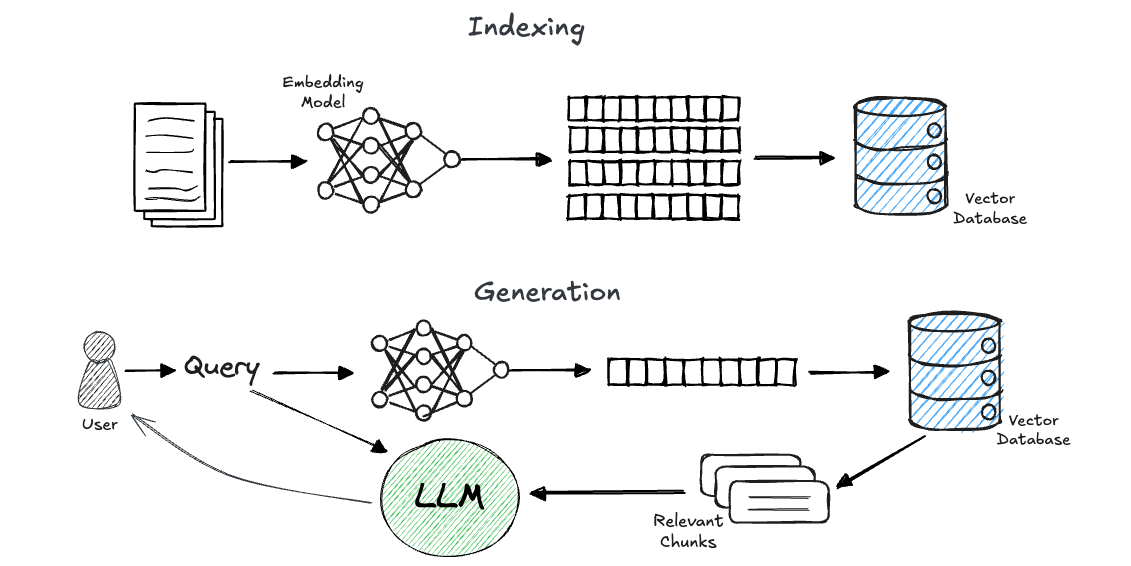

Для обращения к документам, большим файлам, базе знаний и подобному обычно используется Ретривер (Retriever) - это поисковый компонент в системах с LLM, который по запросу находит нужные фрагменты во внешней базе и подкладывает их модели в промпт.

В текущем занятии мы будем использовать некоторые эвристики для извлечения данных, а вот уже полноценный Retriever посмотрим уже в занятии №7, однако метаданные документов **уже настоящие**: `document_id`, `version`, `valid_from`, `valid_to`, `Order_no`. На следующем занятии мы заменим тело функции на гибридный поиск, а всё, что построено вокруг сигнатуры, останется работать.

P.S. Все примеры носят иллюстративный характер и никак не отражают текущие документы Сбера.

In [9]:
# создадим некоторый набор нормативных документов, которые описывают положения о тарифах
TARIFF_SNIPPETS = [
    {
        "document_id": "TARIFF-CASH-001", "version": 3,
        "valid_from": "2026-01-01", "valid_to": "2026-06-30",
        "order_no": "Приказ № 114-Т от 18.12.2025", "product": "СберКарта",
        "text": ("Снятие наличных в банкоматах сторонних банков по карте «СберКарта»: "
                 "комиссия 2,0 % от суммы превышающий лимит, минимум 200 ₽. Лимит без комиссии - 10 000 ₽/день."),
    },
    {
        "document_id": "TARIFF-CASH-001", "version": 4,
        "valid_from": "2026-07-01", "valid_to": "2099-12-31",
        "order_no": "Приказ № 62-Т от 05.06.2026", "product": "СберКарта",
        "text": ("Снятие наличных в банкоматах сторонних банков по карте «СберКарта»: "
                 "комиссия 2,0 % от суммы превышающий лимит, минимум 200 ₽. Лимит без комиссии в сторонних банкоматах - 0 ₽/день."),
    },
    {
        "document_id": "DISPUTE-RULES-007", "version": 2,
        "valid_from": "2026-02-01", "valid_to": "2099-12-31",
        "order_no": "Приказ № 9-О от 20.01.2026", "product": "ДБО",
        "text": ("Заявление на оспаривание операции принимается в течение 60 дней с даты операции. "
                 "Обязательные сведения: дата, сумма, валюта, канал, наименование точки. "
                 "Срок рассмотрения - до 30 календарных дней, по картам МПС - до 45."),
    },
    {
        "document_id": "TARIFF-CASH-001", "version": 4,
        "valid_from": "2026-07-01", "valid_to": "2099-12-31",
        "order_no": "Приказ № 62-Т от 05.06.2026", "product": "Премиум",
        "text": ("Снятие наличных в банкоматах сторонних банков по карте «Премиум»: "
                 "без комиссии до 1 000 000 ₽/мес и 100 000 ₽/день соответсвенно, далее 1,0 %, минимум 100 ₽."),
    },
    {
        "document_id": "SBP-LIMITS-013", "version": 1,
        "valid_from": "2026-05-01", "valid_to": "2099-12-31",
        "order_no": "Приказ № 41-П от 22.04.2026", "product": "СБП",
        "text": ("Переводы через СБП физическим лицам: без комиссии до 100 000 ₽ в месяц, "
                 "далее 0,5 %. Зачисление - до 1 минуты, при оспаривании платяжа - до 3 рабочих дней."),
    },
]

def format_citation(doc: dict) -> str:
    return f"[{doc['document_id']} v.{doc['version']} действ. с {doc['valid_from']} - {doc['order_no']}]"

def retrieve_stub(query: str, slots: CaseData, k: int = 3) -> list[dict]:
    """Функция ретривера. На занятии 7 мы заменим эту функцию гибридным поиском,
    сигнатура и формат возврата сохраняются."""
    op_date = slots.operation_date
    scored = []
    for doc in TARIFF_SNIPPETS:
        score = 0.0
        # лексическое пересечение
        q_words = set(re.findall(r"[а-яёa-z]+", query.lower()))
        d_words = set(re.findall(r"[а-яёa-z]+", doc["text"].lower()))
        score += len(q_words & d_words) / max(len(q_words), 1)
        # продуктовый фильтр
        if slots.product and doc["product"] == slots.product:
            score += 0.5
        # проверка даты: документ должен действовать на дату операции
        if op_date:
            if doc["valid_from"] <= op_date <= doc["valid_to"]:
                score += 1.0
            else:
                score -= 1.0
        scored.append((score, doc))
    scored.sort(key=lambda x: -x[0])
    return [doc for score, doc in scored[:k] if score > 0]

for label, slots in [
    ("операция 2026-06-14 (июнь)", CaseData(product="СберКарта", operation_date="2026-06-14")),
    ("операция 2026-08-01 (август)", CaseData(product="СберКарта", operation_date="2026-08-01")),
]:
    print(f"--- {label} ---")
    for doc in retrieve_stub("комиссия за снятие наличных в чужом банкомате", slots, k=2):
        print("  ", format_citation(doc))
    print()

--- операция 2026-06-14 (июнь) ---
   [TARIFF-CASH-001 v.3 действ. с 2026-01-01 - Приказ № 114-Т от 18.12.2025]
   [DISPUTE-RULES-007 v.2 действ. с 2026-02-01 - Приказ № 9-О от 20.01.2026]

--- операция 2026-08-01 (август) ---
   [TARIFF-CASH-001 v.4 действ. с 2026-07-01 - Приказ № 62-Т от 05.06.2026]
   [TARIFF-CASH-001 v.4 действ. с 2026-07-01 - Приказ № 62-Т от 05.06.2026]



**Пояснения к результату:**
- Один и тот же вопрос даёт **разные корректные** документы для июньской и августовской операции.
- `format_citation` фиксирует **дисциплину цитирования**: `document_id` + `version` + `valid_from` + номер приказа. В банке оператор должен иметь возможность открыть ровно ту редакцию, на которую сослался агент.
- Здесь наша функция возвращает список словарей - тот же контракт, что и настоящий ретривер занятия 7. Поэтому менять граф нам не придется.

## Раздел 4. Sliding window и Summarization: `trim_messages` и свёртка истории

Две базовые стратегии сокращения истории диалога:

- **Sliding window** (`trim_messages`) - держим только последние сообщения, влезающие в бюджет. Дёшево, без вызовов LLM, но всё что не попадает в окно теряется.
- **Summarization** - все что не попало в окно суммаризируется в саммари и сохраняется в диалоге. Дороже (нужен вызов модели), зато детали частично сохраняются.

В проде их комбинируют: свёртка по достижении порога + окно последних сообщений. Важная тонкость `trim_messages`: нельзя разрывать пару `AIMessage(tool_calls)` → `ToolMessage`, иначе API отклонит запрос. За это отвечают `start_on` и `end_on`.

Наш **промпт суммаризации специализирован под кейс**: он обязан сохранять слоты заявления и версии процитированных документов. Универсальная сводка «клиент спрашивал про комиссии» уничтожает именно то, что нужно.

In [4]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, AnyMessage
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
import textwrap

# Инициализируем отдельный экземпляр для суммаризации (можно с другими параметрами)
llm_summarizer = llm

SUMMARY_PROMPT = """Твоя задача вести протокол обращения в поддержку Сбера.
Суммаризируй переписку в структурированную сводку. ОБЯЗАТЕЛЬНО сохрани дословно:
- все собранные реквизиты заявления (дата операции, сумма, валюта, канал, продукт и т.д.);
- все процитированные документы в формате [ID v.N действ. с ДАТА];
- достигнутые договорённости и обещания клиенту;
- нерешённые вопросы.
Опусти вежливые формулы и повторы. Максимум 200 слов, без вступлений.

ПРЕДЫДУЩАЯ СВОДКА:
{previous}

НОВАЯ ЧАСТЬ ПЕРЕПИСКИ:
{chunk}"""

def summarize_chunk(previous: str, messages: list[AnyMessage]) -> str:
    chunk = "\n".join(
        f"{'Клиент' if isinstance(m, HumanMessage) else 'Агент'}: {m.content}"
        for m in messages if isinstance(m, (HumanMessage, AIMessage)) and m.content
    )
    prompt = SUMMARY_PROMPT.format(previous=previous or "(пусто)", chunk=chunk)
    return llm_summarizer.invoke([HumanMessage(content=prompt)]).content.strip()

# Демонстрация trim_messages на синтетической истории
history = []
for i in range(1, 9):
    history.append(HumanMessage(content=f"Реплика клиента номер {i} про комиссию и сроки рассмотрения заявления."))
    history.append(AIMessage(content=f"Ответ агента номер {i} со ссылкой на TARIFF-CASH-001 v.3."))

trimmed = trim_messages(
    history,
    strategy="last",
    token_counter=count_tokens_approximately,
    max_tokens=200,
    start_on="human",       # окно всегда начинается с реплики человека
    end_on=("human", "ai"), # и не обрывает пару tool_call -> tool_result
    include_system=True,
)

print(f"Было сообщений: {len(history)}, осталось в окне: {len(trimmed)}")
print(f"Токенов (оценка): {count_tokens_approximately(history)} -> {count_tokens_approximately(trimmed)}")

# Суммаризируем то, что «выпало» из окна
dropped_messages = history[:len(history) - len(trimmed)]
if dropped_messages:
    print("\nСаммари части, которая не попала:\n")
    summary = summarize_chunk("", dropped_messages)
    print(textwrap.fill(summary, 100))

Было сообщений: 16, осталось в окне: 10
Токенов (оценка): 320 -> 200

Саммари части, которая не попала:

**Реквизиты заявления:**   Отсутствуют.  **Процитированные документы:**   [TARIFF-CASH-001 v.3]
**Достигнутые договоренности и обещания клиенту:**   Нет.  **Нерешенные вопросы:**   Комиссия и
сроки рассмотрения заявления остаются предметом обсуждения. Клиент трижды поднимал этот вопрос,
однако агент каждый раз ссылается исключительно на тарифный документ [TARIFF-CASH-001 v.3].
Конкретные детали проблемы, обстоятельства возникновения спора, реквизиты заявки и другая
необходимая информация клиентом не предоставлены.


## Importance Scoring: что из диалога уходит в долговременную память

`trim_messages` работает с позицией, суммаризация - с текстом. Ни то, ни другое не решает, какие **факты о клиенте** должны попасть из сессии в долговременный `Store` после закрытия обращения.

Для этого нужен третий механизм - **importance scoring**. Он гибридный, и включает несколько этапов:

- **дешёвый детерминированный слой** (правила, regex) отбирает кандидатов - работает на каждом ходу, без вызова модели;
- **дорогой слой на LLM** решает только по кандидатам, прошедшим порог.

Если же мы будем использовать обратный порядок: «спросим модель на каждом ходу», то это существенно умножает стоимость диалога и на сороковой реплике диалога становится заметно.

In [5]:
MEMORY_WORTHY_PATTERNS = {
    "operation_ref": (r"\b\d{1,3}[\s ]?\d{3}([.,]\d{2})?\s*(₽|руб)", 3.0),
    "date":          (r"\b(\d{1,2}[.\-/]\d{1,2}[.\-/]\d{2,4}|\d{4}-\d{2}-\d{2})\b", 2.5),
    "card_product":  (r"\b(классик|премиум|платин)\w*", 2.5),
    "contact":       (r"([\w.\-]+@[\w.\-]+\.\w+|\+7[\d\s()\-]{10,})", 3.0),
    "complaint":     (r"\b(жалоб|оспор|оспарив|претенз|некоррект|незаконн)\w*", 2.5),
    # Предпочтение по каналу связи - долговременный факт о клиенте, поэтому вес
    # выставлен выше порога: одного такого сигнала достаточно, чтобы дойти до LLM-судьи.
    "preference":    (r"(предпочит|удобн[оей]|не звоните|нет отвеча|только в чат|пишите (на|мне))", 2.5),
}
IMPORTANCE_THRESHOLD = 2.0

class MemoryCandidate(BaseModel):
    """Информация, которую стоит сохранить в долговременную память клиента."""
    is_durable: bool = Field(description="Факт полезен в БУДУЩИХ обращениях этого клиента?")
    attribute: str = Field(description="Короткое имя атрибута, snake_case, например preferred_channel")
    value: str = Field(description="Нормализованное значение факта")
    reason: str = Field(description="Одно предложение обоснования")

candidate_llm = llm.with_structured_output(MemoryCandidate)

def rule_score(text: str) -> tuple[float, list[str]]:
    """Дешёвый слой: сколько сигналов значимости в реплике."""
    score, hits = 0.0, []
    low = text.lower()
    for name, (pattern, weight) in MEMORY_WORTHY_PATTERNS.items():
        if re.search(pattern, low):
            score += weight
            hits.append(name)
    if text.strip().endswith("?") and score < 4:
        score -= 1.0   # чистый вопрос редко несёт долговременный факт о клиенте
    return max(score, 0.0), hits

def judge_candidate(text: str) -> Optional[MemoryCandidate]:
    """Дорогой слой: вызывается только для реплик, прошедших порог."""
    try:
        return candidate_llm.invoke([
            SystemMessage(
                "Ты решаешь, стоит ли сохранить факт из реплики клиента в долговременную память "
                "ассистента поддержки банка. Долговременный факт - тот, что будет полезен через "
                "месяцы в НОВОМ обращении (продукт, предпочтения, устойчивые обстоятельства). "
                "Реквизиты одной конкретной операции - НЕ долговременный факт, они живут в заявлении."),
            HumanMessage(text),
        ])
    except Exception as exc:
        print("  [memory] LLM-судья недоступен:", type(exc).__name__)
        return None

probe_turns = [
    "14 июня снял 30 000 рублей в банкомате Сбера, комиссия 100 рублей",
    "А какие вообще сроки рассмотрения?",
    "Пишите мне только в чат, я на звонки не отвечаю",
    "Спасибо большое, до свидания",
    "У меня карта Классик и ещё вклад открыт с прошлого года",
]
for turn in probe_turns:
    score, hits = rule_score(turn)
    gate = "ПОРОГ ПРОЙДЕН" if score >= IMPORTANCE_THRESHOLD else "отсечено правилами"
    print(f"[{score:4.1f}] {gate:18s} {hits} | {turn}")
    if score >= IMPORTANCE_THRESHOLD:
        verdict = judge_candidate(turn)
        if verdict:
            mark = "ЗАПИСАТЬ" if verdict.is_durable else "не писать"
            print(f"        -> LLM: {mark}: {verdict.attribute}={verdict.value!r} ({verdict.reason})")
    print()

[ 3.0] ПОРОГ ПРОЙДЕН      ['operation_ref'] | 14 июня снял 30 000 рублей в банкомате Сбера, комиссия 100 рублей
        -> LLM: не писать: none='none' (Реквизиты одной конкретной операции не сохраняются в долговременной памяти.)

[ 0.0] отсечено правилами [] | А какие вообще сроки рассмотрения?

[ 2.5] ПОРОГ ПРОЙДЕН      ['preference'] | Пишите мне только в чат, я на звонки не отвечаю
        -> LLM: ЗАПИСАТЬ: preferred_channel='chat' (Клиент предпочитает получать сообщения только в чате, не отвечает на звонки.)

[ 0.0] отсечено правилами [] | Спасибо большое, до свидания

[ 2.5] ПОРОГ ПРОЙДЕН      ['card_product'] | У меня карта Классик и ещё вклад открыт с прошлого года
        -> LLM: ЗАПИСАТЬ: has_classic_card='true' (Клиент подтвердил наличие карты Классик, что полезно знать для будущих обращений.)



## Раздел 6. Иерархия памяти в стиле MemGPT/Letta вручную на LangGraph Store

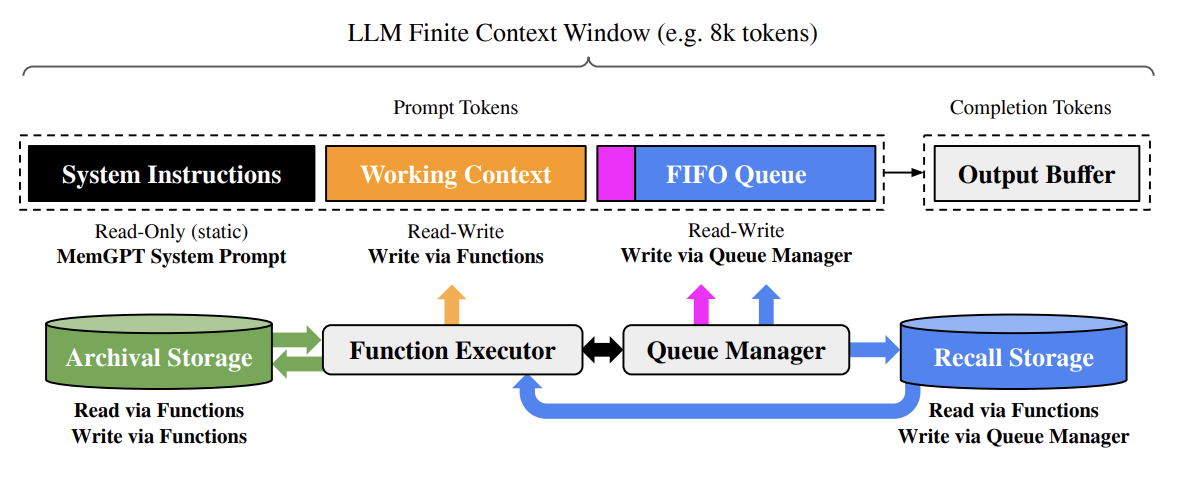

Основная идея рассмотрена в статье про **MemGPT** (arXiv:2310.08560, октябрь 2023), актуальная реализацию можно найти в [**Letta**](https://github.com/letta-ai/letta). Идея: контекст модели это RAM, и им надо управлять как операционная система управляет памятью. Следует разделять несколько уровней:

- **core** - всегда в промпте, маленький и дорогой (профиль продуктов клиента);
- **recall** - текущая сессия, доступна через поиск (наша `messages` + сводка);
- **archival** - практически неограниченный склад с подгрузкой по запросу (история прошлых обращений).

Letta требует PostgreSQL и Docker, поэтому в практике мы **воспроизводим иерархию вручную** используя `InMemoryStore` из LangGraph. При этом мы самостоятельно можем задать логику вытеснения (eviction) и подкачки (paging).

In [6]:
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import InMemorySaver

store = InMemoryStore()
CLIENT_ID = "client-4471"

def ns_core(client_id: str) -> tuple:
    return ("Sber", client_id, "core")

def ns_archival(client_id: str) -> tuple:
    return ("Sber", client_id, "archival")

CORE_BUDGET_TOKENS = 220   # жёсткий лимит блока core в промпте

def core_put(client_id: str, attribute: str, value: str, importance: float = 1.0):
    """Запись в core с вытеснением наименее важного при переполнении бюджета."""
    store.put(ns_core(client_id), attribute,
              {"attribute": attribute, "value": value,
               "importance": importance, "updated_at": time.time()})
    _evict_core(client_id)

def _core_items(client_id: str) -> list:
    return list(store.search(ns_core(client_id), limit=100))

def core_block(client_id: str) -> str:
    items = sorted(_core_items(client_id), key=lambda i: -i.value["importance"])
    if not items:
        return ""
    lines = [f"- {i.value['attribute']}: {i.value['value']}" for i in items]
    return "ПРОФИЛЬ КЛИЕНТА (core memory):\n" + "\n".join(lines)

def _evict_core(client_id: str):
    """Вытеснение core -> archival: выбывает наименее важное, а при равной важности - старое."""
    while count_tokens_approximately([SystemMessage(core_block(client_id))]) > CORE_BUDGET_TOKENS:
        items = _core_items(client_id)
        if len(items) <= 1:
            return
        victim = min(items, key=lambda i: (i.value["importance"], i.value["updated_at"]))
        store.put(ns_archival(client_id), f"evicted::{victim.key}::{int(victim.value['updated_at'])}",
                  dict(victim.value, evicted_from="core"))
        store.delete(ns_core(client_id), victim.key)
        print(f"  [EVICT] core -> archival: {victim.key}={victim.value['value']!r} "
              f"(importance={victim.value['importance']})")

def archival_page_in(client_id: str, query: str, limit: int = 2) -> list[dict]:
    """Страничная подкачка: достаём из archival то, что относится к текущему запросу."""
    q_words = set(re.findall(r"[а-яёa-z]{4,}", query.lower()))
    hits = []
    for item in store.search(ns_archival(client_id), limit=200):
        text = f"{item.value.get('attribute','')} {item.value.get('value','')}".lower()
        overlap = len(q_words & set(re.findall(r"[а-яёa-z]{4,}", text)))
        if overlap:
            hits.append((overlap, item.value))
    hits.sort(key=lambda x: -x[0])
    if hits:
        print(f"  [PAGE-IN] archival -> контекст: {len(hits[:limit])} записей")
    return [v for _, v in hits[:limit]]

# Наполняем профиль: важность задана осознанно
core_put(CLIENT_ID, "products", "карта «СберКарта» с 2024-03, вклад «Классик» с 2025-11", importance=5.0)
core_put(CLIENT_ID, "preferred_channel", "только чат, звонки не принимает", importance=4.0)
core_put(CLIENT_ID, "region", "Новосибирская область", importance=2.0)
core_put(CLIENT_ID, "last_dispute", "оспаривание комиссии за снятие, июнь 2026", importance=3.0)
core_put(CLIENT_ID, "app_version", "мобильное приложение 8.2.1 на Android 14", importance=1.0)
core_put(CLIENT_ID, "small_talk", "упоминал, что переехал в новый район", importance=0.5)

print("\nCORE BLOCK:")
print(core_block(CLIENT_ID))
print(f"\nТокенов в core: {count_tokens_approximately([SystemMessage(core_block(CLIENT_ID))])} "
      f"(бюджет {CORE_BUDGET_TOKENS})")
print()
archival_page_in(CLIENT_ID, "приложение android версия")


CORE BLOCK:
ПРОФИЛЬ КЛИЕНТА (core memory):
- products: карта «СберКарта» с 2024-03, вклад «Классик» с 2025-11
- preferred_channel: только чат, звонки не принимает
- last_dispute: оспаривание комиссии за снятие, июнь 2026
- region: Новосибирская область
- app_version: мобильное приложение 8.2.1 на Android 14
- small_talk: упоминал, что переехал в новый район

Токенов в core: 92 (бюджет 220)



[]

**Пояснения к результату:**
- Вытеснение выбило `small_talk` и `app_version` - наименее важное. Сравните с LRU: там первым бы выбыл `products`, самый ценный факт. **Политика вытеснения - продуктовое решение, а не техническая деталь.**
- `archival_page_in` возвращает вытесненное обратно, когда разговор затрагивает именно эту тему. Именно так и работает страничная подкачка MemGPT: факт не потерян, он выгружен в специальное место. Здесь также возможно использование эмбеддингов и retriever для поиска необходимых фактов.
- Поиск в archival здесь - наивное пересечение слов. Далее в программе он станет семантическим с recency-взвешиванием, мы получим для этого настоящий гибридный ретривер.

## Раздел 7. Собираем диалоговый контур: граф LangGraph

Теперь соеденим всё вместе. Наш граф в LangGraph на каждом ходу выполняет:

1. `budget_guard` - проверяет бюджет, при превышении порога сворачивает историю и обрезает окно;
2. `slot_filling` - извлекает слоты и **добавляет** их в накопленное состояние полей клиента;
3. `retrieve` - простой ретривер с временным фильтром по `operation_date`;
4. `generate` - собирает контекст по приоритетам и отвечает с обязательным цитированием клиенту;
5. `memory_write` - importance scoring и запись в `Store`;
6. `reflect` - каждые N сообщений генерирует некоторый факт/вывод из диалога

Итоговая цепочка:
`budget_guard` → `slot_filling` → `retrieve` → `generate` → `memory_write` → `reflect`

При этом мы фиксируем **приоритет блоков контекста** в `generate` и это важно, поскольку мы можем регулировать глубину контекста с помощью добавления в эту цепочку: system → core memory → саммари → подкачанное из archival → найденные документы → окно последних сообщений.

Здесь порядок стабилен от сообщения к сообщению - так префикс контекста меняется минимально. У GigaChat кэш префикса включается заголовком X-Session-ID, и стабильный порядок блоков – именно то, что даёт ему срабатывать.

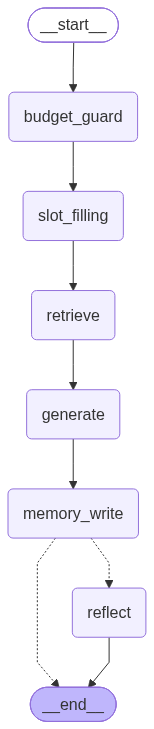

In [7]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

REFLECT_EVERY = 8
SUMMARY_TRIGGER_TOKENS = 900
WINDOW_TOKENS = 600

class SupportState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    slots: dict
    summary: str
    turn_no: int
    client_id: str
    budget_log: list
    citations: list
    folded_upto: int   # сколько первых сообщений уже свёрнуто в summary

SYSTEM_PROMPT = """Ты - ассистент клиентской поддержки российского банка «Сбер».\n\n# ТВОИ ЗАДАЧИ\nОбъяснять тарифы и условия, сообирать статус переводов, помогать с картами,\nпринимать заявления на оспаривание операций, эскалировать обращения, которые невозможно решить на оператора.\n
# ЧЕГО ТЫ НЕ ДЕЛАЕШЬ\nне переводишь и не возвращаешь деньги, не обещаешь решения по диспуту,\nне даёшь инвестиционных советов.\n
# ПРАВИЛО ЦИТИРОВАНИЯ\nЛюбое утверждение о тарифе, сроке или лимите сопровождай ссылкой в формате [ID v.N действ. с ДАТА] из блока НАЙДЕННЫЕ ДОКУМЕНТЫ.\nЕсли в блоке нет документа, подтверждающего утверждение, — скажи, что уточнишь у оператора.\nНикогда не цитируй версию документа, не действовавшую на дату операции клиента.\n
Отвечай кратко и по делу, на русском. Если для заявления не хватает реквизитов - спроси\nне более двух самых важных за один ход."""

def merge_slots(current: dict, new: CaseData) -> dict:
    """Функция для обновления состояний: новое непустое значение перекрывает старое значение, пустое - не стирает."""
    merged = dict(current)
    for key, value in new.model_dump(exclude_none=True).items():
        merged[key] = value
    return merged

def live_window(state: SupportState) -> list[AnyMessage]:
    """Текущее окно. Всё, что до folded_upto, уже живёт в summary."""
    return state["messages"][state.get("folded_upto", 0):]

def node_budget_guard(state: SupportState) -> dict:
    """Инкрементальная свертка: суммаризируем только то, что выпало из окна впервые.
    Без folded_upto каждое новое сообщение после порога заново суммаризировалось бы
    и это добавляет лишний вызов LLM на каждом новом сообщенииб саммари также нарастает."""
    tail = live_window(state)
    tokens = count_tokens_approximately(tail)
    entry = {"turn": state["turn_no"], "messages": len(state["messages"]),
             "history_tokens_est": tokens, "action": "none"}
    updates: dict = {}
    if tokens > SUMMARY_TRIGGER_TOKENS:
        kept = trim_messages(tail, strategy="last", token_counter=count_tokens_approximately,
                             max_tokens=WINDOW_TOKENS, start_on="human",
                             end_on=("human", "ai"), include_system=False)
        newly_dropped = tail[:len(tail) - len(kept)]
        if newly_dropped:
            updates["summary"] = summarize_chunk(state.get("summary", ""), newly_dropped)
            updates["folded_upto"] = state.get("folded_upto", 0) + len(newly_dropped)
            entry.update(action="summarize+trim", dropped=len(newly_dropped),
                         history_tokens_after=count_tokens_approximately(kept))
    return {**updates, "budget_log": state.get("budget_log", []) + [entry]}

def node_slot_filling(state: SupportState) -> dict:
    last_user = state["messages"][-1]
    extracted = extract_fields(last_user.content)
    return {"slots": merge_slots(state.get("slots", {}), extracted)}

def node_retrieve(state: SupportState) -> dict:
    slots = CaseData(**{k: v for k, v in state["slots"].items() if k in CaseData.model_fields})
    docs = retrieve_stub(state["messages"][-1].content, slots, k=3)
    return {"citations": docs}

def node_generate(state: SupportState) -> dict:
    client_id = state["client_id"]
    blocks = [SYSTEM_PROMPT]                                    # 1. приоритет: инструкции

    core = core_block(client_id)                                # 2. профиль клиента
    if core:
        blocks.append(core)

    if state.get("summary"):
        blocks.append("СВОДКА РАНЕЕ СКАЗАННОГО:\n" + state["summary"])

    slots_filled = {k: v for k, v in state.get("slots", {}).items() if v is not None}
    if slots_filled:                                            # 4. собранные реквизиты
        blocks.append("СОБРАННЫЕ РЕКВИЗИТЫ ЗАЯВЛЕНИЯ:\n" +
                      json.dumps(slots_filled, ensure_ascii=False, indent=1))

    paged = archival_page_in(client_id, state["messages"][-1].content)
    if paged:                                                   # 5. подкачка из archival
        blocks.append("ИЗ ИСТОРИИ ОБРАЩЕНИЙ:\n" +
                      "\n".join(f"- {p['attribute']}: {p['value']}" for p in paged))

    docs = state.get("citations", [])
    if docs:                                                    # 6. найденные документы
        blocks.append("НАЙДЕННЫЕ ДОКУМЕНТЫ:\n" + "\n\n".join(
            f"{format_citation(d)}\n{d['text']}" for d in docs))

    system = SystemMessage("\n\n".join(blocks))
    # 7. окно последних реплик - только из несвёрнутой части истории
    window = trim_messages(live_window(state), strategy="last",
                           token_counter=count_tokens_approximately,
                           max_tokens=WINDOW_TOKENS, start_on="human",
                           end_on=("human", "ai"), include_system=False)

    response = llm.invoke([system] + window)

    # Контроль дисциплины цитирования: если утверждение о тарифе без ссылки - одна переспрашивающая попытка.
    needs_citation = bool(re.search(r"\b(комисси|тариф|лимит|срок|проценто?в?)\w*", response.content.lower()))
    has_citation = "[" in response.content and "v." in response.content
    if docs and needs_citation and not has_citation:
        response = llm.invoke([system] + window + [
            AIMessage(response.content),
            HumanMessage("Ты нарушил правило цитирования: утверждение о тарифе или сроке без ссылки "
                         "[ID v.N действ. с ДАТА]. Перепиши ответ со ссылкой на документ из блока "
                         "НАЙДЕННЫЕ ДОКУМЕНТЫ.")])

    usage = response.usage_metadata or {}
    log = state.get("budget_log", [])
    if log:
        log[-1].update(system_tokens_est=count_tokens_approximately([system]),
                       window_messages=len(window),
                       actual_input_tokens=usage.get("input_tokens"),
                       actual_output_tokens=usage.get("output_tokens"))
    return {"messages": [response], "budget_log": log, "turn_no": state["turn_no"] + 1}

def node_memory_write(state: SupportState) -> dict:
    text = state["messages"][-2].content if len(state["messages"]) >= 2 else ""
    score, _ = rule_score(text)
    if score >= IMPORTANCE_THRESHOLD:
        verdict = judge_candidate(text)
        if verdict and verdict.is_durable:
            core_put(state["client_id"], verdict.attribute, verdict.value,
                     importance=min(score, 5.0))
            print(f"  [MEMORY] core <- {verdict.attribute}={verdict.value!r}")
    return {}

def node_reflect(state: SupportState) -> dict:
    episodes = [f"{i.value['attribute']}: {i.value['value']}"
                for i in store.search(ns_core(state["client_id"]), limit=50)]
    if not episodes:
        return {}
    insight = llm_summarizer.invoke([HumanMessage(
        "Сформулируй один практический вывод для оператора поддержки о том, как вести себя с этим "
        "клиентом, опираясь только на факты ниже. Не выдумывай новых фактов. Одно предложение.\n\n"
        + "\n".join(episodes))]).content.strip()
    store.put(ns_core(state["client_id"]), "operator_hint",
              {"attribute": "operator_hint", "value": insight,
               "importance": 3.5, "updated_at": time.time()})
    print(f"  [REFLECT] {insight}")
    return {}

def should_reflect(state: SupportState) -> str:
    return "reflect" if state["turn_no"] % REFLECT_EVERY == 0 else END

graph = StateGraph(SupportState)
graph.add_node("budget_guard", node_budget_guard)
graph.add_node("slot_filling", node_slot_filling)
graph.add_node("retrieve", node_retrieve)
graph.add_node("generate", node_generate)
graph.add_node("memory_write", node_memory_write)
graph.add_node("reflect", node_reflect)

graph.add_edge(START, "budget_guard")
graph.add_edge("budget_guard", "slot_filling")
graph.add_edge("slot_filling", "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", "memory_write")
graph.add_conditional_edges("memory_write", should_reflect, {"reflect": "reflect", END: END})
graph.add_edge("reflect", END)

# InMemorySaver = short-term память: состояние живёт между вызовами в рамках thread_id.
checkpointer = InMemorySaver()
app = graph.compile(checkpointer=checkpointer)

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

**Пояснения к результату:**
- `thread_id` = номер обращения клиента. Все, что накопилось в `SupportState`, остается внутри данного обращения - это **short-term (thread-scoped) память** через checkpointer.
- `Store` живёт **вне** `thread_id`: записанное там доступно в следующем обращении. Это **long-term (cross-thread) память**.
- Условное ребро на вызов `reflect` используется, чтобы `reflect` вызывался только на N сообщений, а не на каждое.
- В `node_generate` собирается ровно тот порядок блоков, который мы определили ранее

## Практика

Прогоняем диалог из 40-ка реплик клиента (будем считать это одной длинной сессией). Клиент **на 3-м ходу** называет дату операции, а потом вклинивает посторонние вопросы про вклад, приложение и СБП, размывая контекст. Проверяем: **на 38-м ходу агент все помнит дату**.

Диалог длинный, поэтому:
- `MAX_TURNS` можно снизить до 12–16, чтобы сэкономить контекст
- `VERBOSE` нужен для управления печатью ответов

In [10]:
DIALOGUE = [
    "Здравствуйте! У меня вопрос по комиссии за снятие наличных.",
    "Карта СберКарта, снимал в банкомате Альфа-банка.",
    "Операция была 14 июня 2026 года, сумма 30000 рублей.",
    "С меня удержали 600 рублей, а я вот смотрел в условиях на сайте написано 200. Почему?",
    "А это законно вообще?",
    "Хорошо, а как оспорить, если я не согласен?",
    "Кстати, а по вкладу какая сейчас ставка?",
    "Понятно. А капитализация ежемесячная?",
    "Ладно, вернёмся к комиссии. Хочу оформить заявление.",
    "Регион - Новосибирская область.",
    "Пишите мне только в чат, на звонки я не отвечаю.",
    "А сколько по времени рассматривается такое заявление?",
    "У меня ещё приложение обновилось и стало тормозить.",
    "Версия 8.2.1, Android 14.",
    "Ладно, про приложение потом. Что там с заявлением?",
    "Валюта рублёвая, конечно.",
    "Банкомат был в торговом центре, называется вроде «Галерея».",
    "А если решение будет не в мою пользу, что дальше?",
    "Понял. А через СБП есть комиссия за перевод?",
    "А если больше 100 тысяч в месяц?",
    "Хорошо. Так, а моё заявление уже оформлено?",
    "Что ещё нужно от меня?",
    "Канал - банкомат, я же говорил.",
    "Ещё раз: тип обращения - оспаривание комиссии.",
    "А почему вообще тариф поменялся в июле?",
    "То есть в июне действовал старый тариф?",
    "Ага. То есть 250 рублей - это правильно было?",
    "Тогда зачем мне оспаривать, если всё по тарифу?",
    "Ладно, а на будущее - как не платить эту комиссию?",
    "20 тысяч в месяц без комиссии - это с июля?",
    "А по Премиуму какие условия?",
    "Сколько стоит переход на Премиум?",
    "Хорошо, подумаю. Заявление тогда отменяем.",
    "А зафиксируйте, что я обращался, на случай если передумаю.",
    "Спасибо за помощь.",
    "Ой, ещё один вопрос: перевод по СБП вчера не дошёл.",
    "Получатель говорит, что ничего не получил.",
    "Напомните, пожалуйста, дату и сумму той операции, по которой я жаловался?",
    "Да, всё верно. Спасибо.",
    "До свидания!",
]

MAX_TURNS = int(os.environ.get("MAX_TURNS", 40))
VERBOSE = True
THREAD = {"configurable": {"thread_id": "case-2026-08-13-0091"}}

state_init = {"messages": [], "slots": {}, "summary": "", "turn_no": 1,
              "client_id": CLIENT_ID, "budget_log": [], "citations": [], "folded_upto": 0}

t_start = time.time()
result = None
for idx, user_text in enumerate(DIALOGUE[:MAX_TURNS], start=1):
    payload = {"messages": [HumanMessage(user_text)]}
    if idx == 1:
        payload = {**state_init, **payload}
    result = app.invoke(payload, config=THREAD)
    if VERBOSE:
        print(f"\n--- СООБЩЕНИЕ №{idx} ---")
        print(f"Пользователь: {user_text}")
        print(f"Агент: {textwrap.fill(result['messages'][-1].content, 100)}")

print(f"\n\nДиалог из {min(MAX_TURNS, len(DIALOGUE))} ходов пройден за {time.time() - t_start:.0f} с")


--- СООБЩЕНИЕ №1 ---
Пользователь: Здравствуйте! У меня вопрос по комиссии за снятие наличных.
Агент: Для точного расчета комиссии мне нужна сумма и дата вашего снятия наличных. Согласно действующему
тарифу [TARIFF-CASH-001 v.4 действ. с 2026-07-01], комиссия составляет 2% от суммы сверх лимита,
минимальный сбор — 200 рублей.

--- СООБЩЕНИЕ №2 ---
Пользователь: Карта СберКарта, снимал в банкомате Альфа-банка.
Агент: Понял. Мне нужны сумма и дата снятия, чтобы точно рассчитать комиссию по текущему тарифу [TARIFF-
CASH-001 v.4 действ. с 2026-07-01].

--- СООБЩЕНИЕ №3 ---
Пользователь: Операция была 14 июня 2026 года, сумма 30000 рублей.
Агент: По вашему запросу: операция 14.06.2026, сумма 30 000₽. По актуальному тарифу [TARIFF-CASH-001 v.4
действ. с 2026-07-01]:   Комиссия составит 400₽ (превышение дневного беспроцентного лимита 10 000₽
на 20 000₽ × 2%). Нужны дополнительные разъяснения?

--- СООБЩЕНИЕ №4 ---
Пользователь: С меня удержали 600 рублей, а я вот смотрел в условиях на сайте 

In [ ]:
# --- Проверка главного: помнит ли агент дату операции из 3-го хода? ---
final_slots = result["slots"]
print("Состояние полей в конце диалога:")
print(json.dumps({k: v for k, v in final_slots.items() if v is not None},
                 ensure_ascii=False, indent=2))

expected = {"operation_date": "2026-06-14", "disputed_fee": 600.0, "product": "СберКарта"}
print("\nКонтроль сохранности ранних реквизитов:")
for key, want in expected.items():
    got = final_slots.get(key)
    ok = "OK " if (got is not None and str(want).rstrip("0.") in str(got).rstrip("0.")) else "ПОТЕРЯНО"
    print(f"  {ok:9s} {key}: ожидали {want!r}, в состоянии {got!r}")

print("\nПоследний ответ Агента (сообщение с вопросом «напомните дату и сумму»):")
for msg in reversed(result["messages"]):
    if isinstance(msg, AIMessage) and re.search(r"\d{2}", msg.content):
        print(textwrap.fill(msg.content, 100)); break

In [ ]:
# --- Трассировка бюджета контекста по ходам ---
print(f"{'ход':>4} {'сообщ':>6} {'ист.оц':>7} {'сист.оц':>8} {'ФАКТ вх':>8} {'вых':>5}  действие")
print("-" * 72)
for e in result["budget_log"]:
    print(f"{e['turn']:>4} {e['messages']:>6} {e['history_tokens_est']:>7} "
          f"{e.get('system_tokens_est', 0):>8} {str(e.get('actual_input_tokens') or '-'):>8} "
          f"{str(e.get('actual_output_tokens') or '-'):>5}  {e['action']}")

facts = [e for e in result["budget_log"] if e.get("actual_input_tokens")]
if facts:
    total_in = sum(e["actual_input_tokens"] for e in facts)
    total_out = sum(e.get("actual_output_tokens") or 0 for e in facts)
    est_sum = sum(e["history_tokens_est"] + e.get("system_tokens_est", 0) for e in facts)
    print(f"\nИТОГО фактически: вход {total_in} токенов, выход {total_out}")
    print(f"Сумма наших оценок: {est_sum} -> расхождение с фактом {(est_sum - total_in)/total_in:+.1%}")
    print(f"Средний вход на ход: {total_in / len(facts):.0f} токенов")
    print("\nБез свёртки и окна вход рос бы линейно: к 40-му сообщению это несколько тысяч токенов на сообщение.")

print("\n\nCORE MEMORY В КОНЦЕ ДИАЛОГА (переживёт закрытие обращения):")
print(core_block(CLIENT_ID))
print("\nARCHIVAL (вытесненное, доступно через подкачку):")
for item in store.search(ns_archival(CLIENT_ID), limit=20):
    print(f"  - {item.value['attribute']}: {item.value['value']}")

In [ ]:
try:
    from langchain.agents import create_agent
    from langchain.agents.middleware import SummarizationMiddleware
    from langchain_core.tools import tool

    @tool
    def find_tariff(query: str, operation_date: str = "") -> str:
        """Найти пункт тарифов или регламента Сбера.
        query: суть вопроса; operation_date: дата операции YYYY-MM-DD для выбора версии документа."""
        slots = CaseData(operation_date=operation_date or None)
        docs = retrieve_stub(query, slots, k=2)
        if not docs:
            return "Ничего не найдено, нужна эскалация на оператора."
        return "\n\n".join(f"{format_citation(d)}\n{d['text']}" for d in docs)

    agent = create_agent(
        model=llm,
        tools=[find_tariff],
        system_prompt=SYSTEM_PROMPT,
        middleware=[SummarizationMiddleware(
            model=llm_summarizer,
            trigger=("tokens", 1200),
            keep=("messages", 8),
        )],
        checkpointer=InMemorySaver(),
    )
    out = agent.invoke(
        {"messages": [HumanMessage(
            "Снимал 12500 руб в чужом банкомате 14 июня 2026 по карте Классик, "
            "удержали 250 руб вместо 199. Объясни почему.")]},
        config={"configurable": {"thread_id": "mw-demo"}},
    )
    print(textwrap.fill(out["messages"][-1].content, 100))
except ImportError as exc:
    print("API LangChain v1 недоступен в этой версии пакета:", exc)
    print("Основной путь занятия - ручной граф выше - работает независимо от этого.")
except Exception as exc:
    print(f"Ветка middleware не выполнилась ({type(exc).__name__}: {exc}).")
    print("Это ожидаемо при расхождении версий; ручной граф выше остаётся рабочим.")

**Пояснения к результату:**
- Здесь ретривер оформлен как `@tool`, и агент **сам решает**, вызывать его или нет. Это шаг от фиксированной RAG-цепочки к агентному retrieval - именно в этом виде мы продолжим на занятии 7.
- Middleware удобнее, но менее прозрачен: вы не видите, что и когда именно свернулось. Для отладки бюджета контекста ручной узел с `budget_log` полезнее.

## Итоги

В этом уроке мы:
1. Научились считать **бюджет контекста по фактическому usage** GigaChat и увидели, на сколько врёт эвристика `count_tokens_approximately` на русском тексте.
2. Собрали **диалоговую систему со специальными полями** через structured output с обязательной fallback-ветвью, и научились накапливать и валидировать эти поля так, что значения из 3-го сообщения в диалоге продолжает быть доступным на 38-м.
3. Реализовали **дисциплину цитирования версий** документов: `document_id` + `version` + `valid_from` + приказ, с автоматической переспрашивающей попыткой при нарушении.
4. Применили **Sliding window** (`trim_messages`) и **Summarization** со специализированным под кейс промптом свёртки, увидев цену потери деталей.
5. Построили двухслойный **Importance Scoring** (дешёвые правила → LLM-судья) и **Reflection** по счётчику ходов.
6. Воспроизвели вручную **иерархию памяти MemGPT/Letta** (core / recall / archival) на LangGraph `Store` с вытеснением по важности и страничной подкачкой.
7. Собрали всё в граф LangGraph с short-term памятью через `InMemorySaver` и long-term через `Store`, с фиксированным **приоритетом блоков контекста**.

## Полезные материалы

- [Память в LangGraph](https://langchain-ai.github.io/langgraph/concepts/memory/) – checkpointer и Store из этого занятия: короткая и долгая память, устройство и API.
- [Middleware агентов в LangChain 1.0](https://docs.langchain.com/oss/python/langchain/middleware) – SummarizationMiddleware из последней ячейки и остальные готовые middleware: когда хватает их, а когда нужен свой узел.
- [trim_messages](https://python.langchain.com/docs/how_to/trim_messages/) – все стратегии обрезки истории: по токенам, по числу сообщений, с сохранением системного сообщения.
- [Context Rot: How Increasing Input Tokens Impacts LLM Performance](https://research.trychroma.com/context-rot) – исследование Chroma о том, как качество ответов деградирует с ростом контекста; экспериментальное обоснование всего занятия.
- [Effective context engineering for AI agents](https://www.anthropic.com/engineering/effective-context-engineering-for-ai-agents) – инженерные приёмы работы с контекстом от Anthropic: что класть в промпт, что выносить наружу.
- [Generative Agents: Interactive Simulacra of Human Behavior](https://arxiv.org/abs/2304.03442) – статья, из которой пришёл механизм reflection: значимость записей, порождение выводов из наблюдений.
- [MemGPT: Towards LLMs as Operating Systems](https://arxiv.org/abs/2310.08560) – иерархия памяти «рабочий контекст + внешнее хранилище», которую занятие воспроизводит вручную.